In [4]:
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
car_data=pd.read_csv('/content/car_age_price.csv')

In [6]:
car_data.head()

,Year,Price
0,2018,465000
1,2019,755000
2,2019,700000
3,2018,465000
4,2018,465000


In [7]:
car_data.shape

(112, 2)

In [8]:
car_data.describe()

,Year,Price
count,112.000000,112.000000
mean,2016.669643,483866.044643
std,1.629616,91217.450533
min,2013.000000,300000.000000
25%,2015.000000,423750.000000
50%,2017.000000,500000.000000
75%,2017.000000,550000.000000
max,2020.000000,755000.000000


In [9]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Year    112 non-null    int64
 1   Price   112 non-null    int64
dtypes: int64(2)
memory usage: 1.9 KB


In [10]:
car_data.isna().sum()

,0
Year,0
Price,0


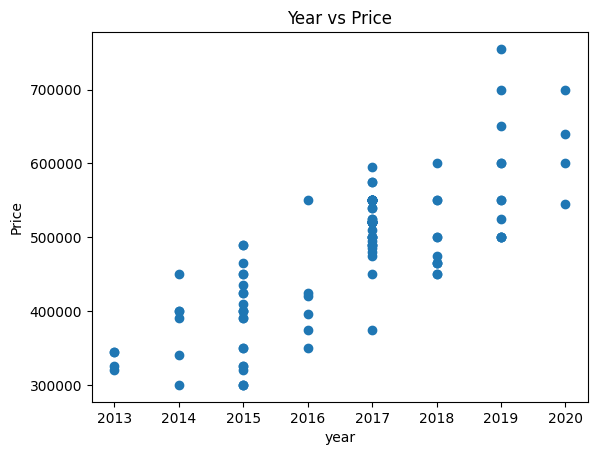

In [11]:
#year vs price
plt.scatter(car_data['Year'],car_data['Price'])
plt.xlabel('year')
plt.ylabel('Price')
plt.title('Year vs Price')
plt.show()

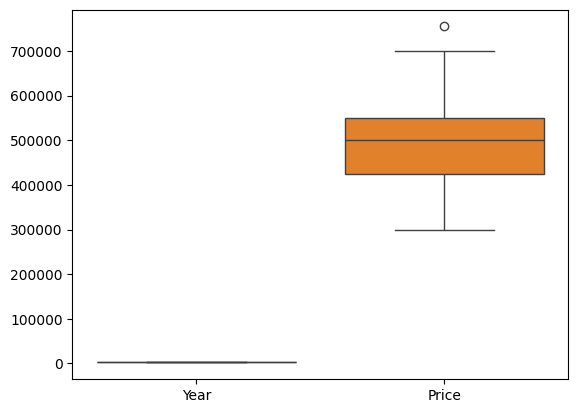

In [12]:
sns.boxplot(car_data)
plt.show()

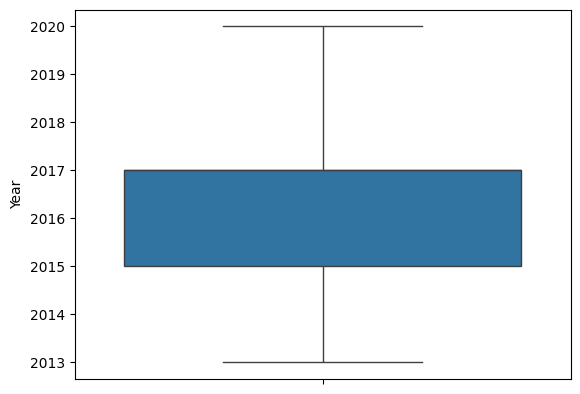

In [13]:
sns.boxplot(car_data['Year'])
plt.show()

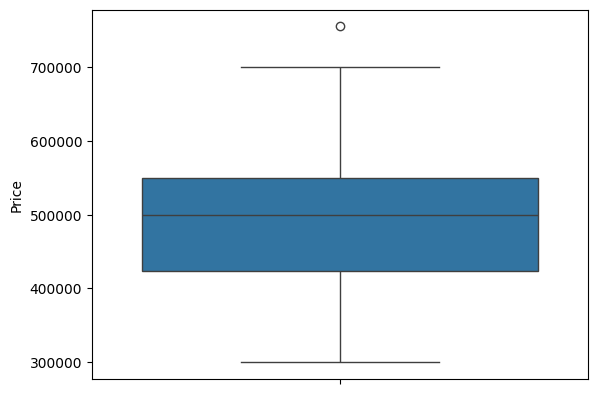

In [14]:
sns.boxplot(car_data['Price'])
plt.show()

In [15]:
q1 = car_data['Price'].quantile(0.25)
q2 = car_data['Price'].quantile(0.50)
q3 = car_data['Price'].quantile(0.75)

In [16]:
print(f'Q1 = {q1}\nQ2= {q2}\nQ3= {q3}')

Q1 = 423750.0
Q2= 500000.0
Q3= 550000.0


In [17]:
iqr = q3-q1
up_lim = q3 + (1.5*iqr)
low_lim = q1 - (1.5*iqr)
print(f'IQR={iqr}\nUp_lim = {up_lim}\nLow_lim = {low_lim}')

IQR=126250.0
Up_lim = 739375.0
Low_lim = 234375.0


In [18]:
(car_data[car_data['Price']>up_lim])

,Year,Price
1,2019,755000


In [19]:
(car_data[car_data['Price']<low_lim])

,Year,Price


In [20]:
(car_data[car_data['Price']>up_lim]).index

Index([1], dtype='int64')

In [21]:
outliers = car_data[(car_data['Price']>up_lim) |(car_data['Price']<low_lim) ]

In [22]:
outliers

,Year,Price
1,2019,755000


In [23]:
outliers.index

Index([1], dtype='int64')

In [24]:
car_data = car_data.drop([1])

In [25]:
#feature target splitting
y =car_data['Price']
x =car_data.drop('Price', axis=1)

In [26]:
  from sklearn.model_selection import train_test_split
  x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [27]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [28]:
model=lr.fit(x_train,y_train)

In [29]:
y_pred=model.predict(x_test)

In [30]:
y_test

,Price
79,400000
11,500000
5,350000
85,320000
65,495000
69,300000
31,550000
46,500000
97,640000
12,500000


In [31]:
y_pred

array([418695.08304033, 541198.43288521, 418695.08304033, 418695.08304033,
       500363.98293692, 418695.08304033, 500363.98293692, 582032.8828335 ,
       622867.33278179, 500363.98293692, 418695.08304033, 377860.63309203,
       541198.43288521, 418695.08304033, 500363.98293692, 500363.98293692,
       500363.98293692, 337026.18314373, 459529.53298862, 582032.8828335 ,
       582032.8828335 , 500363.98293692, 500363.98293692])

In [32]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test,y_pred)
r2 =r2_score(y_test,y_pred)
print('mean_squared_error:',mse)
print('r2_score:',r2)

mean_squared_error: 2360736941.0488067
r2_score: 0.7087665874512326


In [43]:
car_data = model.predict([[2022]])
print(car_data)

[704536.23267838]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Lasso Regression

In [33]:
from sklearn.linear_model import Lasso

In [34]:
lm = Lasso(alpha=1.0 , max_iter=1000)
lm.fit(x_train, y_train)

Lasso()

In [37]:
print("Lasso Coefficient:", lm.coef_)
print("Lasso Intercept:", lm.intercept_)

Lasso Coefficient: [40834.04953464]
Lasso Intercept: -81861914.06494312


In [38]:
lasso_pred = lm.predict(x_test)
print(lasso_pred)

[418695.74736297 541197.8959669  418695.74736297 418695.74736297
 500363.84643225 418695.74736297 500363.84643225 582031.94550155
 622865.99503618 500363.84643225 418695.74736297 377861.69782832
 541197.8959669  418695.74736297 500363.84643225 500363.84643225
 500363.84643225 337027.64829369 459529.79689762 582031.94550155
 582031.94550155 500363.84643225 500363.84643225]


In [39]:
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Mean Squared Error:", lasso_mse)
print("Lasso R² Score:", lasso_r2)

Lasso Mean Squared Error: 2360749599.6382856
Lasso R² Score: 0.7087650258184441


In [40]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Lasso Regression'],
    'MSE': [mse, lasso_mse],
    'R2 Score': [r2, lasso_r2]
})

print(comparison)

               Model           MSE  R2 Score
0  Linear Regression  2.360737e+09  0.708767
1   Lasso Regression  2.360750e+09  0.708765


In [41]:
if lasso_mse < mse and lasso_r2 > r2:
    print("Lasso Regression performs better.")
elif mse < lasso_mse and r2 > lasso_r2:
    print("Linear Regression performs better.")
else:
    print("The models have mixed performance. Compare MSE and R² to decide.")

Linear Regression performs better.
